# ex-h4 — portfolio variance and frames, true vs estimated

Everything runs through `HedgeRiskModel` in `hedge_pipeline.py`, which bundles one
population model with one estimate of it. You plug in any dollar portfolio:

```python
hrm = HedgeRiskModel(model, n=20, seed=1)   # or HedgeRiskModel(model, Y=your_returns)
hrm = HedgeRiskModel(model, n=20, seed=1, k=3)   # estimate k directions (default: model.k)
hrm = HedgeRiskModel(model, n=20, seed=1,   # heavy tails: any unit-variance sampler
                     factor_sampler=student_t(4), idio_sampler=student_t(4))
hrm.report(x)                               # true (eq. 1.1) vs estimated (eq. 1.3) risk of x
hrm.report({"a": x, "b": y})                # several books: one comparison row each
hrm.report(x, truth=other_model)            # score the "true" side under another Model (same p)
hrm.report(hrm.hedge(x))                    # the same book after the block hedge on span(H)
hrm.show_frames()                           # b̄ vs h angles, and the factor-plane disk at k=2
```

The three sets of directions:

| | what | orthogonal? |
|---|---|---|
| $\beta$ columns of $B$ | economic loadings (market, style) | **no** |
| $\bar b_j$ | eigenvectors of $\Sigma_0=B\Sigma_fB^\top$ | yes, by construction |
| $h_j$ | eigenvectors of the sample $S=YY^\top/(np)$ | yes, by construction |

**Units:** $\Sigma_f$ and $\delta_i^2$ are annualized. Each observation is one trading day with
covariance annual$/252$. Estimated variances are annualized by $\times252$. Vol tables are
quoted annual, daily and over 20 days.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "sim").is_dir():
    if REPO_ROOT == REPO_ROOT.parent:
        raise FileNotFoundError("could not locate repo root (no 'sim' dir above cwd)")
    REPO_ROOT = REPO_ROOT.parent
for _p in (str(REPO_ROOT), str(REPO_ROOT / "hedging")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import pandas as pd
from hedge_pipeline import (HedgeRiskModel, Model, MEMO_BETA, MEMO_DELTA2, DAYS_PER_YEAR,
                            gaussian, student_t, min_variance, min_variance_long_only,
                            ffp_min_variance_long_only, kkt_gap)

pd.options.display.float_format = "{:,.4f}".format

## 1 · The memo's example

`HedgeRiskModel.memo(p, n, seed)` builds the memo's §1.4 model (`p = 10` is its table
exactly; other values truncate or tile its rows) and estimates it from `n` daily draws.
The cosine table shows that the $\beta$ columns aren't orthogonal while the $\bar b_j$ are.

In [2]:
P, N, SEED = 10, 20, 20261001
hrm = HedgeRiskModel.memo(p=P, n=N, seed=SEED)
hrm.summary()

p = 10, n = 20, k true = 2, k estimated = 2;  factor vols [0.16 0.1 ];  mean δ² = 0.0986
returns: factors gaussian, idiosyncratic gaussian
p·μ  (true, Σ0)        = [0.2692 0.0304]
p·θ  (est, annualized) = [0.39   0.2324];   ℓ (daily) = 2.593e-05

       β market  β style     δ²    δ̂²    b̄1     b̄2     h1      h2
asset                                                               
1        0.8800   0.1640 0.0968 0.0585 0.2629  0.2213 0.2305 -0.4682
2        0.8010  -0.7400 0.0647 0.0325 0.2665 -0.3024 0.2761  0.1677
3        0.9630  -0.5750 0.1413 0.0301 0.3108 -0.1853 0.5485 -0.2847
4        1.0630   0.9600 0.0453 0.0468 0.2942  0.6990 0.0825  0.3154
5        1.1700   0.1220 0.1128 0.0686 0.3524  0.2398 0.1261  0.2419
6        1.0170  -1.0390 0.1399 0.0376 0.3414 -0.4403 0.4520  0.3679
7        0.9170  -0.0500 0.0603 0.0510 0.2807  0.1055 0.1160 -0.0556
8        0.8820  -0.6980 0.1437 0.0831 0.2899 -0.2668 0.3970 -0.4383
9        1.1120  -0.3780 0.1402 0.0788 0.3501 -0.0519 0.3565  0

### The equal-weight \$1M book: true vs estimated risk, then block-hedged

In [3]:
x_equal = np.full(hrm.p, 1_000_000 / hrm.p)
_ = hrm.report(x_equal, "equal weight")
print()
_ = hrm.report(hrm.hedge(x_equal), "equal weight, block-hedged on span(H)")

── equal weight:  gross $1,000,000, net $1,000,000
              eigenvalue true (pμ) eigenvalue est (pθ) exposure true (x·b̄) exposure est (x·h)  variance true   variance est share true share est error (est − true)
component                                                                                                                                                           
factor 1                    0.2692              0.3900              313,693            279,640 26,494,851,333 30,493,695,831      72.9%     84.5%      3,998,844,498
factor 2                    0.0304              0.2324                3,451             40,448        361,567    380,170,494       0.0%      1.1%        379,808,927
idiosyncratic                                                                                   9,865,000,000  5,226,519,757      27.1%     14.5%     -4,638,480,243
total                                                                                          36,360,212,900 36,100,386,082

### Population frame vs estimated frame

- **Cross-Gram** $M=\bar B^\top H$: entry $(i,j)$ is $\cos\angle(\bar b_i,h_j)$.
- **Per factor:** the angle each $h_j$ makes with $\bar b_j$ and with the plane span$(B)$.
  $\sin^2\angle(h_j,\bar b_j)$ splits exactly into out-of-subspace plus in-plane rotation.
- **Principal angles** between span$(H)$ and span$(B)$. These don't depend on how either
  frame is labelled or rotated.

In the picture:
- **Gray dashed arrows:** the $\beta$ columns, at unit length and not at right angles.
- **Colored arrows:** each $h_j$ projected onto the plane. The gap to the circle is its
  out-of-subspace part.

cross-Gram M = b̄'H  (cosines):
         h1     h2
b̄1  0.8821 0.1958
b̄2 -0.3541 0.1080

per factor:
    angle to b̄_j (deg)  angle to span(B) (deg)  sin² to b̄_j    = out-of-subspace    + in-plane rotation
h1              28.1067                 18.1041        0.2220               0.0966                 0.1254
h2              83.8022                 77.0806        0.9883               0.9500                 0.0383

principal angles between span(H) and span(B) (deg): {'θ1': 15.99, 'θ2': 80.14}


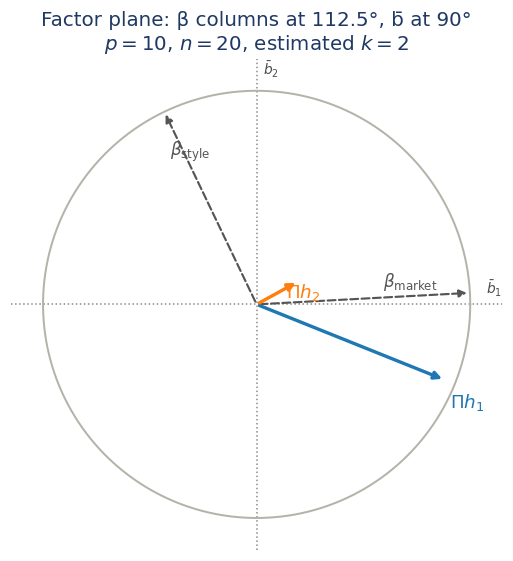

In [4]:
_ = hrm.show_frames()

### The same draw, estimated with $k=3$

Same model, same seed, same returns. The only change is that the risk model now keeps a
third sample direction, $h_3$, even though there are only two true factors. What to look for:
- **$h_1, h_2$ are unchanged.** They are the same top two sample eigenvectors.
- **$h_3$ has no partner $\bar b_3$.** Only its angle to span$(B)$ is reported.
- **span$(H)$ grows by one dimension.** It can only move closer to span$(B)$, so the second
  principal angle drops.
- **The estimated risk moves, the true risk doesn't.** $\hat\delta_i^2$ is now measured after
  projecting out three directions instead of two, so every residual variance shrinks. The
  idiosyncratic estimate falls by much more than the new factor-3 term adds, and the
  estimated total drops. The true factor-3 variance is zero.

In [5]:
hrm3 = HedgeRiskModel.memo(p=P, n=N, seed=SEED, k=3)
assert np.allclose(hrm3.H[:, :2], hrm.H)            # same draw: h1, h2 unchanged
_ = hrm3.report(x_equal, "equal weight, k = 3")
print()
_ = hrm3.report(hrm3.hedge(x_equal), "equal weight, block-hedged on span(H), k = 3")

── equal weight, k = 3:  gross $1,000,000, net $1,000,000
              eigenvalue true (pμ) eigenvalue est (pθ) exposure true (x·b̄) exposure est (x·h)  variance true   variance est share true share est error (est − true)
component                                                                                                                                                           
factor 1                    0.2692              0.3900              313,693            279,640 26,494,851,333 30,493,695,831      72.9%     88.1%      3,998,844,498
factor 2                    0.0304              0.2324                3,451             40,448        361,567    380,170,494       0.0%      1.1%        379,808,927
factor 3                                        0.1760                                  39,964              0    281,041,374       0.0%      0.8%        281,041,374
idiosyncratic                                                                                   9,865,000,000  3,466,

cross-Gram M = b̄'H  (cosines):
         h1     h2     h3
b̄1  0.8821 0.1958 0.0973
b̄2 -0.3541 0.1080 0.2124

per factor:
    angle to b̄_j (deg)  angle to span(B) (deg)  sin² to b̄_j    = out-of-subspace    + in-plane rotation
h1              28.1067                 18.1041        0.2220               0.0966                 0.1254
h2              83.8022                 77.0806        0.9883               0.9500                 0.0383
h3                  NaN                 76.4871           NaN               0.9454                    NaN

principal angles between span(H) and span(B) (deg): {'θ1': 15.95, 'θ2': 73.2}


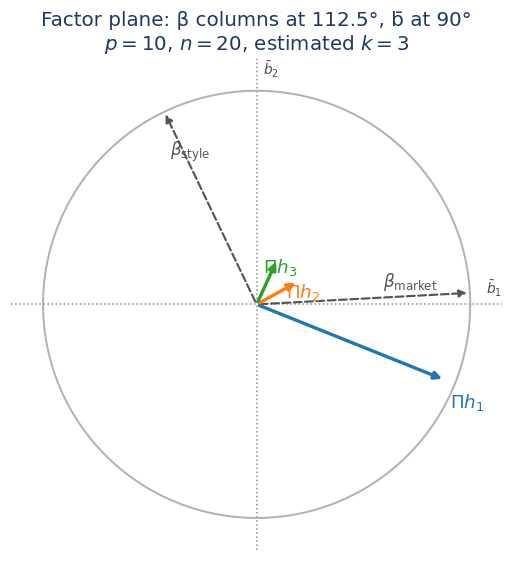

In [6]:
_ = hrm3.show_frames()

## 2 · Run your own

Edit any of the three blocks:
- **Population model:** loadings `B` (p×k), `Sigma_f` (k×k) and `delta2` (p,), all
  annualized. The memo's values are filled in.
- **Returns sampler:** `gaussian`, `student_t(df)`, or any function `f(rng, shape)` that
  returns i.i.d. draws with mean 0 and variance 1. The model's covariances are applied on
  top, so $\Sigma_f$ and $\delta^2$ hold exactly. Only the tails change.
- **Estimator:** `n` and `seed` to draw, or pass `Y=` your own (p, n) daily return panel.
  `k` is how many directions the risk model estimates. It defaults to the true factor count;
  set it lower or higher to misspecify. Extra $h_j$ have no partner $\bar b_j$, so only their
  angle to span$(B)$ is reported.
- **Portfolio:** any length-p dollar vector.

The example book is long the four most style-positive names and short the four most
style-negative ones, \$100k per name.

── style long/short:  gross $800,000, net $0
              eigenvalue true (pμ) eigenvalue est (pθ) exposure true (x·b̄) exposure est (x·h) variance true  variance est share true share est error (est − true)
component                                                                                                                                                         
factor 1                    0.2692              0.2995               -1,836            -42,047       907,154   529,469,599       0.0%      7.6%        528,562,446
factor 2                    0.0304              0.2349              246,040             91,885 1,838,123,630 1,983,534,406      18.6%     28.4%        145,410,776
idiosyncratic                                                                                  8,048,000,000 4,481,731,790      81.4%     64.1%     -3,566,268,210
total                                                                                          9,887,030,784 6,994,735,796     100.0%    100

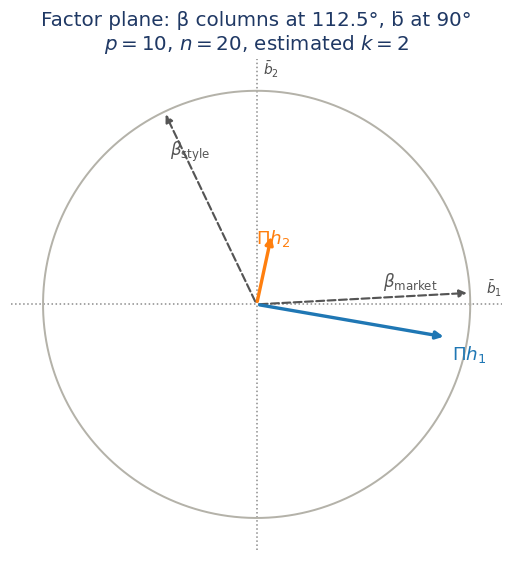

In [7]:
# ── population model ──────────────────────────────────────────────────────────
my_model = Model(
    B=MEMO_BETA.copy(),                          # (p, k) loadings: [market, style]
    Sigma_f=np.diag([0.16**2, 0.10**2]),         # annualized factor covariance
    delta2=MEMO_DELTA2.copy(),                   # annualized idiosyncratic variances
    names=("market", "style"),
)

# ── returns sampler (unit-variance draws; the model supplies the covariance) ──
factor_sampler = gaussian                        # e.g. student_t(4) for heavy tails
idio_sampler = gaussian

# ── estimator ─────────────────────────────────────────────────────────────────
my_k = my_model.k                                # estimated factors; try 1 or 3
my_hrm = HedgeRiskModel(my_model, n=20, seed=7, k=my_k,  # or: Y=your_returns instead of n/seed
                        factor_sampler=factor_sampler, idio_sampler=idio_sampler)

# ── portfolio ─────────────────────────────────────────────────────────────────
style_rank = np.argsort(my_model.B[:, 1])
x_mine = np.zeros(my_model.p)
x_mine[style_rank[-4:]] = 100_000
x_mine[style_rank[:4]] = -100_000

_ = my_hrm.report(x_mine, "style long/short")
print()
_ = my_hrm.show_frames()

### Minimum-variance book

A fully invested \$1M book that minimizes variance:
$x\propto\Sigma^{-1}\mathbf 1$, scaled so $\mathbf 1^\top x=\$1\text{M}$.

- **From the risk model:** built from `Sigma_hat`, the estimated covariance a manager actually has.
- **Oracle:** built from the true $\Sigma_y$, which no manager has. Shown for reference.

All four books in this cell are then scored against the true risk in one comparison table.
`est / true` is estimated over true total vol, so below 1 means the risk model understates. An optimizer leans into directions where the
estimate looks quiet, so the estimate tends to *understate* the risk of its own min-var book.

In [8]:
x_minvar = min_variance(my_hrm.Sigma_hat, 1_000_000)          # what the manager can build
x_minvar_oracle = min_variance(my_model.Sigma_y, 1_000_000)   # needs the true covariance

# several books at once: one comparison row each (detail=True adds the full reports)
_ = my_hrm.report({
    "equal weight":         np.full(my_model.p, 1_000_000 / my_model.p),
    "style long/short":     x_mine,
    "min-var (risk model)": x_minvar,
    "min-var (oracle)":     x_minvar_oracle,
}, windows=(DAYS_PER_YEAR, 20))

print("weights ($k):")
print(pd.DataFrame({"risk model": x_minvar / 1e3, "oracle": x_minvar_oracle / 1e3},
                   index=pd.RangeIndex(1, my_model.p + 1, name="asset")).T
      .to_string(float_format="{:,.1f}".format))

                        gross $      net $ total true total est est / true factor true factor est idio true idio est
vol (annual)                                                                                                        
equal weight         $1,000,000 $1,000,000   $190,684  $168,202       0.88    $162,774   $152,272   $99,323  $71,450
style long/short       $800,000         $0    $99,434   $83,635       0.84     $42,884    $50,130   $89,711  $66,946
min-var (risk model) $1,335,002 $1,000,000   $202,950  $113,557       0.56    $161,921    $61,439  $122,354  $95,501
min-var (oracle)     $1,000,000 $1,000,000   $182,199  $148,330       0.81    $153,784   $126,481   $97,708  $77,488

                        gross $      net $ total true total est est / true factor true factor est idio true idio est
vol (20-day)                                                                                                        
equal weight         $1,000,000 $1,000,000    $53,719   $47,386

### Long-only minimum-variance book

The same problem with no shorts: minimize $x^\top\Sigma x$ subject to $\mathbf 1^\top x=\$1\text{M}$
and $x\ge0$. There's no closed form, so the book comes from a solver:

- **Standard solver:** `min_variance_long_only`. It is exact: it recasts the problem as a
  nonnegative least-squares problem in $\Sigma=LL^\top$ and solves it with SciPy's
  Lawson–Hanson `nnls` (`method="slsqp"` is also available).
- **FFP:** `ffp_min_variance_long_only`, a fixed-point iteration in factor coordinates.
  It uses the factor form $\Sigma=B\,\mathrm{diag}(f)\,B^\top+\mathrm{diag}(s)$ directly. The
  optimum is $w\propto\max(1-B\theta,0)/s$ for a $k$-vector $\theta$, and each step is one
  $k\times k$ solve. `hrm.factor_form()` supplies $(H,\,p\theta,\,\hat\delta^2)$ for the risk model;
  `hrm.factor_form(true=True)` supplies $(\bar B,\,p\mu,\,\delta^2)$ for the oracle.

Both should give the same book, and the weight difference is printed.

**FFP can cycle.** The held set $\{i: b_i^\top\theta\le1\}$ can recur after several steps
($\theta_1\to\theta_2\to\theta_3\to\theta_1$), with no bound on the cycle length. Each step depends on
$\theta$ only through that set, so the code remembers every set it has visited. A set that
recurs after two or more steps is an exact cycle. On a cycle, on hitting `max_iter`, or on a
failed KKT check, FFP warns and falls back to the exact solver (or raises an error with
`fallback="raise"`). `return_info=True` reports which method produced the book.

`kkt_gap` checks optimality. At the optimum, every held name has the same marginal
variance $(\Sigma x)_i$, and every name left at zero has a marginal variance at least that
large. The gap is the worst violation relative to that common value, so 0 means exact.

In [9]:
SOURCES = {"risk model": (my_hrm.Sigma_hat, my_hrm.factor_form()),
           "oracle":     (my_model.Sigma_y, my_hrm.factor_form(true=True))}

books = {}
for src, (Sigma, (B_f, f, s)) in SOURCES.items():
    x_solver = min_variance_long_only(Sigma, 1_000_000)
    x_ffp, ffp_info = ffp_min_variance_long_only(B_f, f, s, 1_000_000, return_info=True)
    books[f"long-only, solver ({src})"] = x_solver
    books[f"long-only, FFP ({src})"] = x_ffp
    for name, xx in [("solver", x_solver), ("FFP", x_ffp)]:
        print(f"{src:10s} {name:6s}  names held {np.sum(xx > 1e-6 * xx.max()):2d}   "
              f"KKT gap {kkt_gap(Sigma, xx):.1e}")
    print(f"{src:10s} FFP: method {ffp_info['method']}, {ffp_info['iterations']} iterations"
          + (f", fell back: {ffp_info['reason']}" if ffp_info["reason"] else ""))
    print(f"{src:10s} max |x_FFP - x_solver| = ${np.abs(x_ffp - x_solver).max():.4f}\n")

_ = my_hrm.report({"equal weight": np.full(my_model.p, 1_000_000 / my_model.p),
                   "min-var (risk model)": x_minvar, **books}, windows=(DAYS_PER_YEAR,))

print("weights ($k):")
print(pd.DataFrame({lab: xx / 1e3 for lab, xx in books.items()},
                   index=pd.RangeIndex(1, my_model.p + 1, name="asset")).T
      .to_string(float_format="{:,.1f}".format))

risk model solver  names held  8   KKT gap 5.8e-16
risk model FFP     names held  8   KKT gap 8.2e-16
risk model FFP: method ffp, 3 iterations
risk model max |x_FFP - x_solver| = $0.0000

oracle     solver  names held 10   KKT gap 2.1e-16
oracle     FFP     names held 10   KKT gap 4.2e-16
oracle     FFP: method ffp, 2 iterations
oracle     max |x_FFP - x_solver| = $0.0000

                                  gross $      net $ total true total est est / true factor true factor est idio true idio est
vol (annual)                                                                                                                  
equal weight                   $1,000,000 $1,000,000   $190,684  $168,202       0.88    $162,774   $152,272   $99,323  $71,450
min-var (risk model)           $1,335,002 $1,000,000   $202,950  $113,557       0.56    $161,921    $61,439  $122,354  $95,501
long-only, solver (risk model) $1,000,000 $1,000,000   $194,597  $121,863       0.63    $164,078    $87,145  $104,62